**Sigmoid** - mathematically, sigmoid never touches exactly 0 or exactly 1 — it only approaches them, forever, no matter how extreme z gets. This property has a name: it's called asymptotic behavior (0 and 1 are asymptotes it never crosses or reaches).

**Why this matters later (a preview):** we're about to build a loss function for classification that involves log(prediction). And log(0) is -∞ — undefined, blows up. If sigmoid could actually output exactly 0 or 1, our loss function would break. The fact that it only gets close is what keeps everything mathematically safe.

**What we already proved, step by step:**

z **> 0 → sigmoid(z) > 0.5 →** prediction rule says "predict 1"

**z < 0 → sigmoid(z) < 0.5 →** prediction rule says "predict 0"

**z = 0 → sigmoid(z) = 0.5 →** the exact tie-breaking boundary

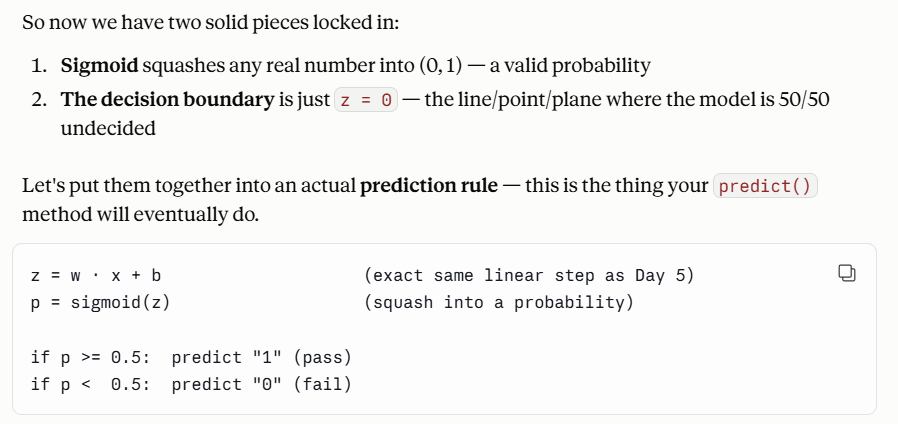

**Pattern to lock in:** -log(1-p) punishes hard when p is close to 1 but y=0 (confidently wrong), and barely punishes when p is close to 0 and y=0 (confidently right). It's the mirror image of the y=1 case.

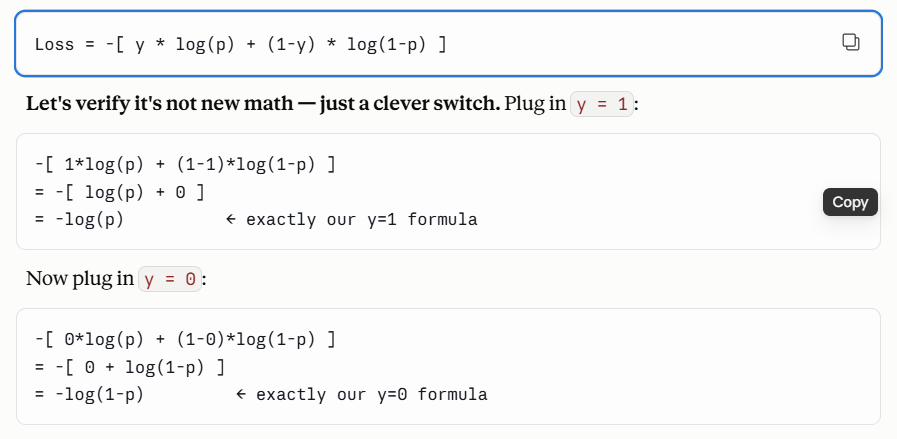

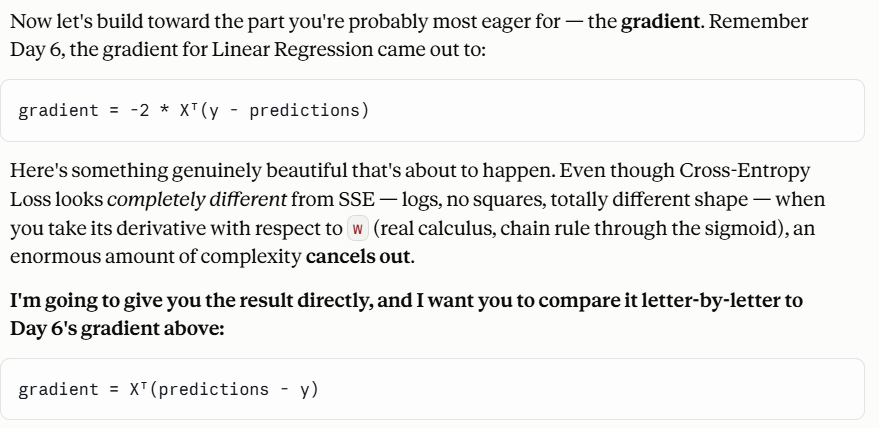

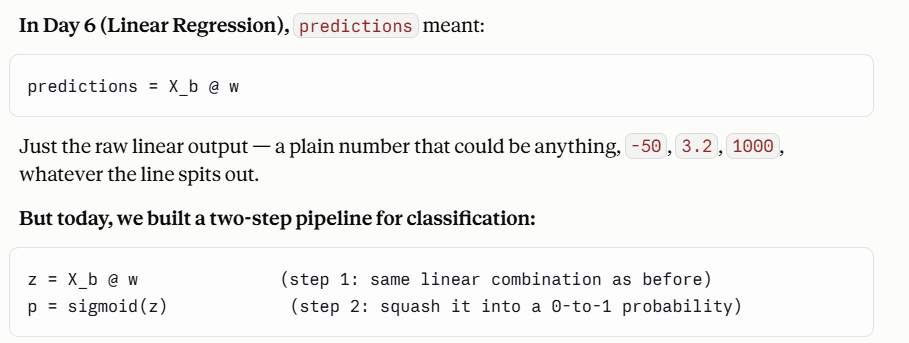

precise gradient is:
```
gradient = Xᵀ(p - y)     where p = sigmoid(X_b @ w)
```
Here's the genuinely elegant part — put Day 6's and today's gradients side by side:
```
Day 6 (Linear Regression):    gradient = Xᵀ(predictions - y)     predictions = X_b @ w
Day 9 (Logistic Regression):  gradient = Xᵀ(predictions - y)     predictions = sigmoid(X_b @ w)
```

In [22]:
import numpy as np

result = np.log(0.6)
print(result)

-0.5108256237659907


In [23]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def fit(self, X, y):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        self.w = np.zeros(X_b.shape[1])

        for i in range(self.n_iterations):
            predictions = sigmoid(X_b @ self.w)
            gradient = X_b.T @ (predictions - y)
            self.w = self.w - self.learning_rate * gradient

            bce = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
            self.loss_history.append(bce)
        return self

    def predict_proba(self, X):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        return sigmoid(X_b @ self.w)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [24]:
import numpy as np

# hours studied
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]], dtype=float)

# pass (1) / fail (0)
y = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1], dtype=float)

In [25]:
model = LogisticRegressionScratch(learning_rate=0.01, n_iterations=10000)
model.fit(X, y)

print("Scratch weights (bias, hours):", model.w)
print("Final loss:", model.loss_history[-1])
print("Predictions:", model.predict(X))
print("Probabilities:", np.round(model.predict_proba(X), 3))

Scratch weights (bias, hours): [-7.12555203  1.29589605]
Final loss: 0.25090335385054974
Predictions: [0 0 0 0 0 1 1 1 1 1]
Probabilities: [0.003 0.011 0.038 0.125 0.344 0.657 0.875 0.962 0.989 0.997]


In [27]:
# Sklearn version

from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression()
sk_model.fit(X, y)

print("sklearn intercept (bias):", sk_model.intercept_)
print("sklearn coef (hours):", sk_model.coef_)
print("sklearn predictions:", sk_model.predict(X))
print("sklearn probabilities:", np.round(sk_model.predict_proba(X)[:, 1], 3))

sklearn intercept (bias): [-4.98275908]
sklearn coef (hours): [[0.90590528]]
sklearn predictions: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
sklearn probabilities: [0.017 0.04  0.094 0.204 0.389 0.611 0.796 0.906 0.96  0.983]


#### Homework 1

Add a second feature (e.g. attendance_pct alongside hours) to the same class, run it, and predict what the decision boundary becomes (you already correctly reasoned earlier that 2 features → a line cutting across 2D space) — then verify that prediction visually.

In [36]:
import numpy as np

# columns: hours studied, attendance %
X2 = np.array([
    [1,  40],
    [2,  50],
    [3,  55],
    [4,  60],
    [5,  70],
    [6,  55],   # same "noisy" student from before — low attendance despite mid hours
    [7,  80],
    [8,  85],
    [9,  90],
    [10, 95],
], dtype=float)

y = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1], dtype=float)   # same labels as before

In [38]:
from warnings import filterwarnings
filterwarnings('ignore')

model2 = LogisticRegressionScratch(learning_rate=0.01, n_iterations=20000)
model2.fit(X2, y)

print("Scratch weights (bias, hours, attendance):", model2.w)
print("Final loss:", model2.loss_history[-1])
print("Predictions:", model2.predict(X2))

Scratch weights (bias, hours, attendance): [-94.42323526  22.64980362  -0.24979382]
Final loss: nan
Predictions: [0 0 0 0 1 1 1 1 1 1]


In [39]:
model2 = LogisticRegressionScratch(learning_rate=0.001, n_iterations=20000)
model2.fit(X2, y)

print("Loss at iteration 0:", model2.loss_history[0])
print("Loss at iteration 1:", model2.loss_history[1])
print("Loss at iteration 5:", model2.loss_history[5])
print("Loss at iteration 20:", model2.loss_history[20])
print("Loss at iteration 100:", model2.loss_history[100])

Loss at iteration 0: 0.6931471805599453
Loss at iteration 1: 2.107941146175698
Loss at iteration 5: 5.804988013926002
Loss at iteration 20: 0.6292263605627018
Loss at iteration 100: 1.7861033191099884


In [42]:
# Fix the nan value

X2_mean = X2.mean(axis=0)
X2_std = X2.std(axis=0)
X2_scaled = (X2 - X2_mean) / X2_std

model2_scaled = LogisticRegressionScratch(learning_rate=0.01, n_iterations=10000)
model2_scaled.fit(X2_scaled, y)

print("Scaled weights (bias, hours, attendance):", model2_scaled.w)
print("Loss at iteration 0:", model2_scaled.loss_history[0])
print("Loss at iteration 100:", model2_scaled.loss_history[100])
print("Final loss:", model2_scaled.loss_history[-1])
print("Predictions:", model2_scaled.predict(X2_scaled))

Scaled weights (bias, hours, attendance): [2.28797372 2.51532832 9.88998175]
Loss at iteration 0: 0.6931471805599453
Loss at iteration 100: 0.17523222200853633
Final loss: 0.009266595885440414
Predictions: [0 0 0 0 1 0 1 1 1 1]


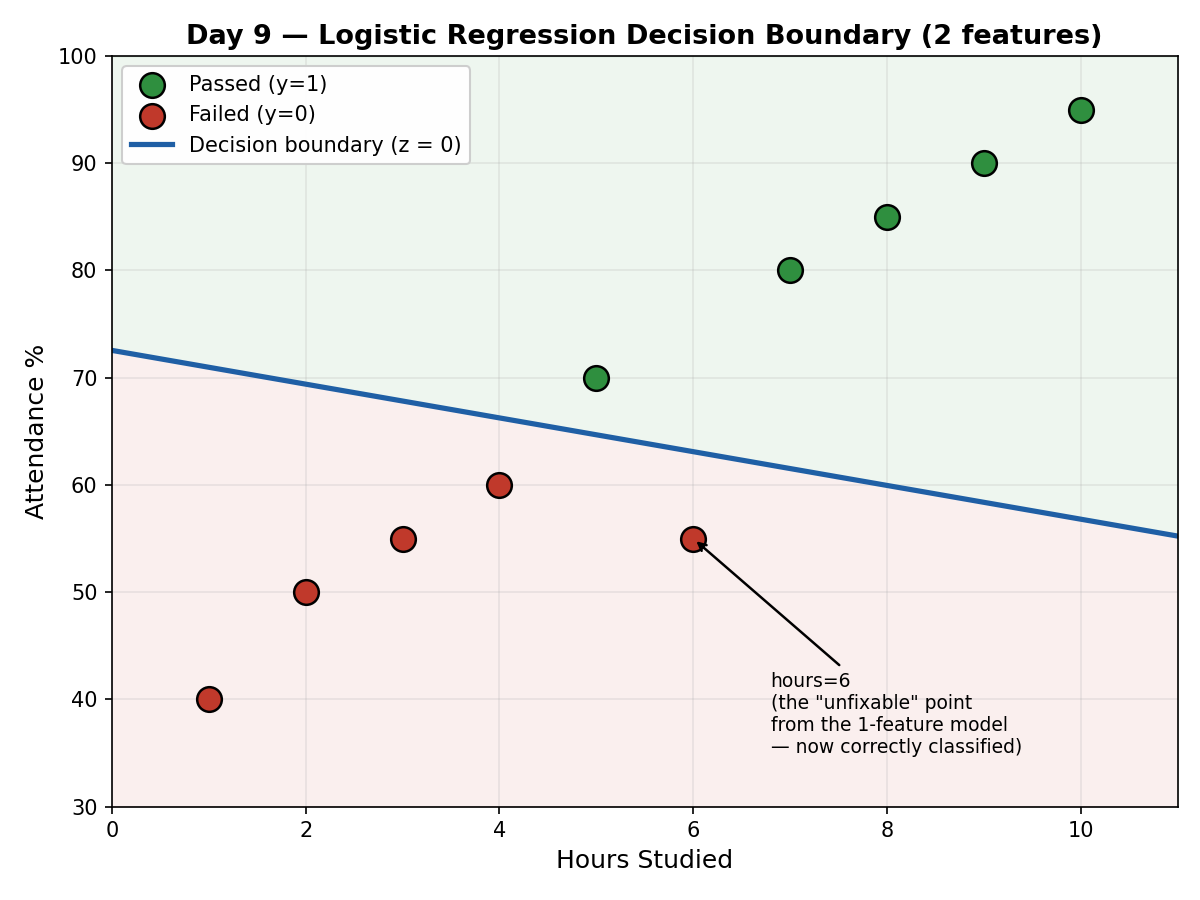